<a href="https://colab.research.google.com/github/nattyix/ML-LAB/blob/main/MLLab1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_diabetes
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt



In [3]:
diabetes = load_diabetes()
x = diabetes.data
y = diabetes.target
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print("Training shape:", x_train.shape)
print("Testing shape:", x_test.shape)

Training shape: (353, 10)
Testing shape: (89, 10)


In [10]:
class LinearRegressionScratch:
  def __init__(self, learning_rate=0.01, n_iters=5000):
    self.lr = learning_rate
    self.n_iters = n_iters
    self.weights = None
    self.bias = None

  def fit(self, x, y):
    n_samples, n_features = x.shape
    self.weights = np.zeros(n_features)
    self.bias = 0
    for _ in range(self.n_iters):
      y_pred = np.dot(x, self.weights) + self.bias
      dw = (2 / n_samples) * np.dot(x.T, (y_pred - y))
      db = (2 / n_samples) * np.sum(y_pred - y)
      self.weights -= self.lr * dw
      self.bias -= self.lr * db

  def predict(self, x):
    y_pred = np.dot(x, self.weights) + self.bias
    return y_pred

In [11]:
model = LinearRegressionScratch()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R^2 Score:", r2)

Mean Squared Error: 3504.346442285607
R^2 Score: 0.33857190042418694


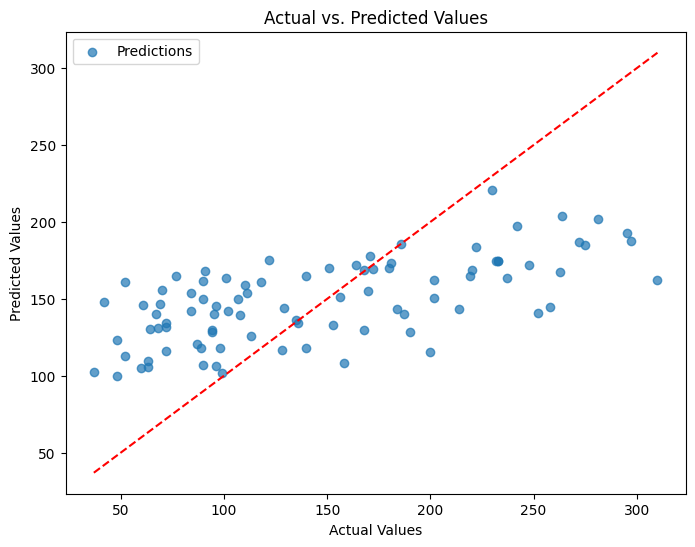

In [12]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7, label = 'Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color = 'red', linestyle = '--')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Values')
plt.legend()
plt.show()